In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

In [10]:
# Load data
df = pd.read_csv('raw/TotalFixations.tsv', sep='\t')
print(f"Loaded {len(df)} rows with {len(df.columns)} columns")

Loaded 594 rows with 10 columns


## Fixation Analysis: Oscuro vs Claro

This analysis calculates and compares total fixations between "Oscuro" (dark mode) and "Claro" (light mode) conditions.

In [ ]:
# Filter data: only single media with Oscuro or Claro conditions
mask = df['Media'].str.contains('Oscuro|Claro', na=False) & ~df['Media'].str.contains(',', na=False)
df_filtered = df[mask].copy()
df_filtered['Condition'] = df_filtered['Media'].str.extract('(Oscuro|Claro)')[0]

# Group by condition
oscuro = df_filtered[df_filtered['Condition'] == 'Oscuro']['Number_of_whole_fixations']
print(f"t-test: t={t_stat:.3f}, p={p_value:.4f} ({'Significant' if p_value < 0.05 else 'Not Significant'})")
print(f"Claro: {claro.sum()} total ({claro.mean():.1f} mean, n={len(claro)})")
print(f"Oscuro: {oscuro.sum()} total ({oscuro.mean():.1f} mean, n={len(oscuro)})")
t_stat, p_value = stats.ttest_ind(oscuro, claro)
# Statistics

claro = df_filtered[df_filtered['Condition'] == 'Claro']['Number_of_whole_fixations']

Conditions found: {'Other': 492, 'Claro': 51, 'Oscuro': 51}
Single media rows: 560, Combined: 34


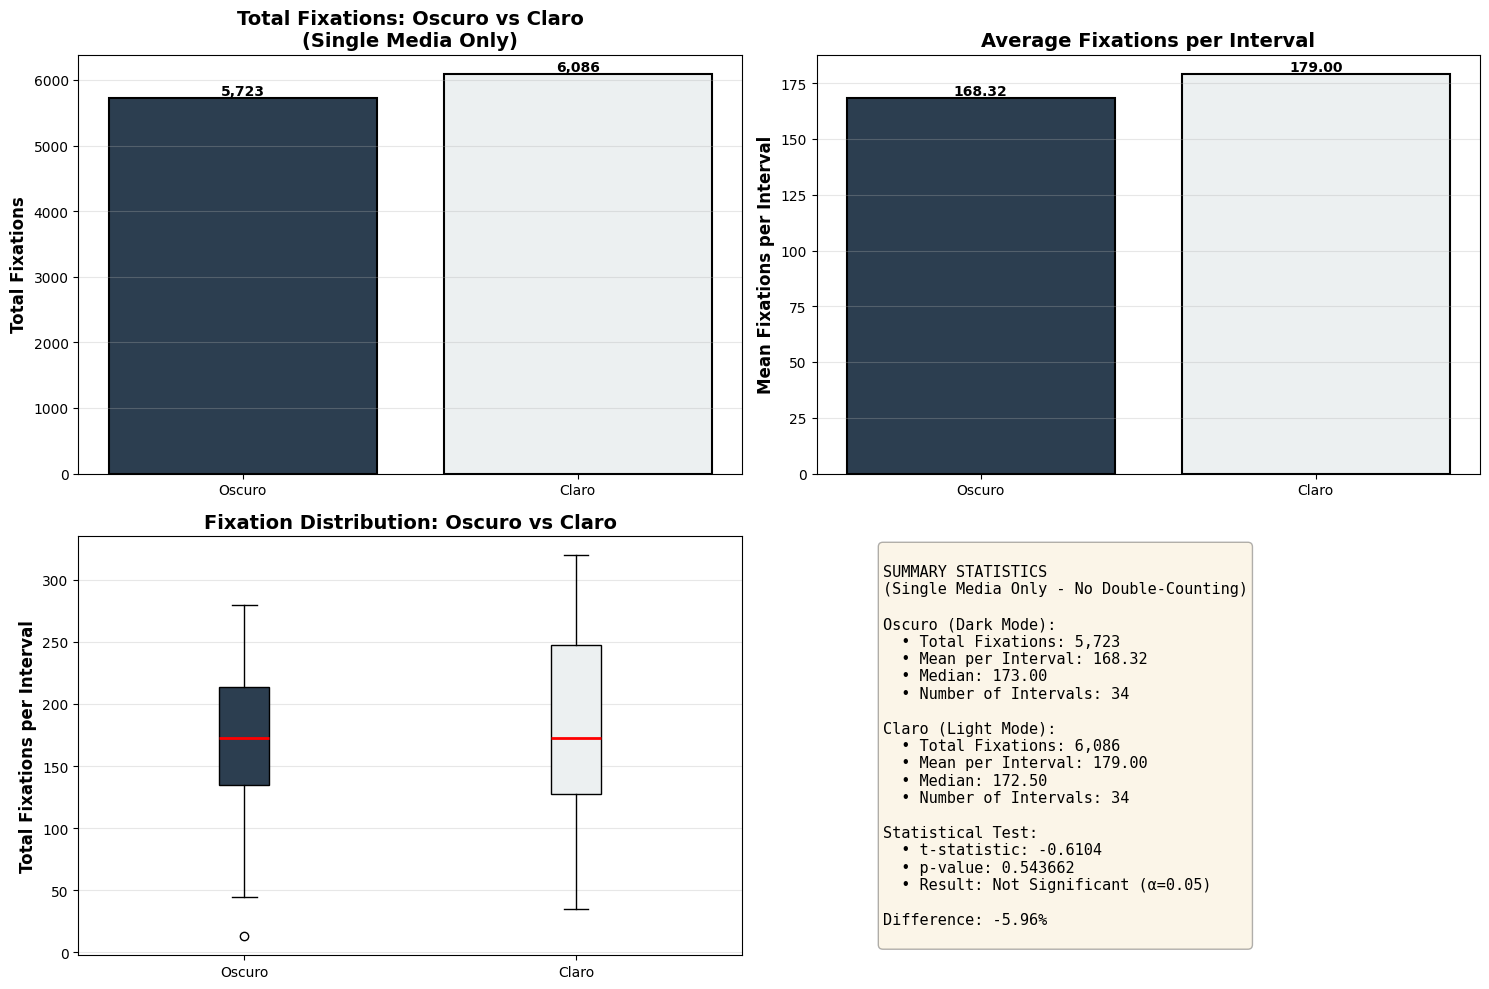


✓ Visualization saved to: output/fixation_comparison_oscuro_vs_claro.png
✓ Analysis excludes combined media rows to prevent double-counting


In [18]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Bar chart - Total Fixations
ax1 = axes[0, 0]
conditions = ['Oscuro', 'Claro']
totals = [fixation_summary.loc[c, 'Total_Fixations'] for c in conditions]
colors = ['#2c3e50', '#ecf0f1']
ax1.bar(conditions, totals, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_ylabel('Total Fixations', fontsize=12, fontweight='bold')
ax1.set_title('Total Fixations: Oscuro vs Claro\n(Single Media Only)', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(totals):
    ax1.text(i, v, f'{int(v):,}', ha='center', va='bottom', fontweight='bold')

# 2. Bar chart - Mean Fixations per Interval
ax2 = axes[0, 1]
means = [fixation_summary.loc[c, 'Mean_Fixations_per_Interval'] for c in conditions]
ax2.bar(conditions, means, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Mean Fixations per Interval', fontsize=12, fontweight='bold')
ax2.set_title('Average Fixations per Interval', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(means):
    ax2.text(i, v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

# 3. Box plot - Distribution comparison
ax3 = axes[1, 0]
data_to_plot = [oscuro_fixations, claro_fixations]
bp = ax3.boxplot(data_to_plot, tick_labels=conditions, patch_artist=True,
                 medianprops=dict(color='red', linewidth=2),
                 boxprops=dict(facecolor='lightblue', edgecolor='black'))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax3.set_ylabel('Total Fixations per Interval', fontsize=12, fontweight='bold')
ax3.set_title('Fixation Distribution: Oscuro vs Claro', fontsize=14, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 4. Summary text
ax4 = axes[1, 1]
ax4.axis('off')
summary_text = f"""
SUMMARY STATISTICS
(Single Media Only - No Double-Counting)

Oscuro (Dark Mode):
  • Total Fixations: {int(total_oscuro):,}
  • Mean per Interval: {fixation_summary.loc['Oscuro', 'Mean_Fixations_per_Interval']:.2f}
  • Median: {fixation_summary.loc['Oscuro', 'Median_Fixations']:.2f}
  • Number of Intervals: {int(fixation_summary.loc['Oscuro', 'Number_of_Intervals'])}

Claro (Light Mode):
  • Total Fixations: {int(total_claro):,}
  • Mean per Interval: {fixation_summary.loc['Claro', 'Mean_Fixations_per_Interval']:.2f}
  • Median: {fixation_summary.loc['Claro', 'Median_Fixations']:.2f}
  • Number of Intervals: {int(fixation_summary.loc['Claro', 'Number_of_Intervals'])}

Statistical Test:
  • t-statistic: {t_stat:.4f}
  • p-value: {p_value:.6f}
  • Result: {'Significant' if p_value < 0.05 else 'Not Significant'} (α=0.05)
  
Difference: {percent_diff:+.2f}%
"""
ax4.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('output/fixation_comparison_oscuro_vs_claro.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to: output/fixation_comparison_oscuro_vs_claro.png")
print("✓ Analysis excludes combined media rows to prevent double-counting")